# Домашнее задание к семинару 12 (HW12)

Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

HW12 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW12/`.

---

## 1. Цель

Закрепить:

- отличие временных рядов от обычных табличных данных с точки зрения валидации;
- практику корректного `temporal split` вместо случайного `random split`;
- построение лаговых, rolling- и календарных признаков;
- сравнение простых baseline-подходов с рекуррентной моделью;
- аккуратное оформление результата: один ноутбук, короткий отчёт, артефакты эксперимента.

---

## 2. Задание

### 2.1. Структура для HW12 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW12/`.
3. В папке `homeworks/HW12/` создать:

- основной ноутбук: `HW12.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`
  - рекомендуется внутри `artifacts/` завести подпапку `figures/` для графиков

> Имена папок и файлов должны быть строго такими, как указано (регистр важен).

---

### 2.2. Датасет для домашней работы

Используйте предоставленный преподавателем CSV-файл:

- `S12-hw-dataset.csv`

Предполагается, что в датасете есть как минимум:

- колонка `date` — временная метка;
- колонка `target` — прогнозируемый числовой ряд.

Допустимо, что в файле будут и дополнительные внешние признаки. Их можно использовать, но обязательная часть домашней работы должна корректно решаться уже на основе самого ряда `target` и производных от него признаков.

Требования к данным:

- использовать **хронологический** порядок наблюдений;
- не перемешивать строки перед разбиением;
- привести колонку `date` к типу datetime и отсортировать данные по времени;
- в ноутбуке показать sanity-check по данным: размер датасета, диапазон дат, наличие/отсутствие пропусков, базовый график ряда;
- если в датасете есть пропуски, выбранный способ обработки нужно кратко объяснить.

Важно:

- использовать `random split` в основной постановке **нельзя**;
- test-часть должна использоваться только для финальной проверки после выбора лучшей модели по `validation`.

---

### 2.3. Содержание ноутбука `HW12.ipynb` (обязательно)

В ноутбуке `homeworks/HW12/HW12.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и среда

1) Импортировать библиотеки: `pandas`, `numpy`, `matplotlib`, `sklearn`, `torch` (и всё, что нужно по делу).
2) Зафиксировать seed (минимум `random`, `numpy`, `torch`).
3) Определить устройство (`cuda` при наличии, иначе `cpu`) и использовать его последовательно.

In [1]:
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Seed для воспроизводимости
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Устройство для обучения
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Создаем директорию для сохранения артефактов
os.makedirs('artifacts/figures', exist_ok=True)

#### 2.3.2. Данные и первичный анализ

1) Загрузить `S12-hw-dataset.csv`.
2) Привести `date` к datetime и отсортировать строки по времени.
3) Показать:
   - число наблюдений;
   - диапазон дат;
   - число пропусков по колонкам;
   - базовый график временного ряда.
4) Кратко прокомментировать ряд: тренд, сезонность, выбросы, возможную нестационарность.

In [2]:
df = pd.read_csv('S12-hw-dataset.csv')

# Приводим date к datetime и сортируем по времени
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Число наблюдений: {len(df)}')
print(f'Диапазон дат: {df["date"].min().date()} - {df["date"].max().date()}')
print(f'Колонки: {list(df.columns)}')
print()
print('Пропуски по колонкам:')
print(df.isnull().sum())
print()
print('Первые строки:')
df.head()

Число наблюдений: 4320
Диапазон дат: 2025-01-01 - 2025-06-29
Колонки: ['date', 'target']

Пропуски по колонкам:
date      0
target    0
dtype: int64

Первые строки:


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


Пропусков нет, данные готовы к анализу.


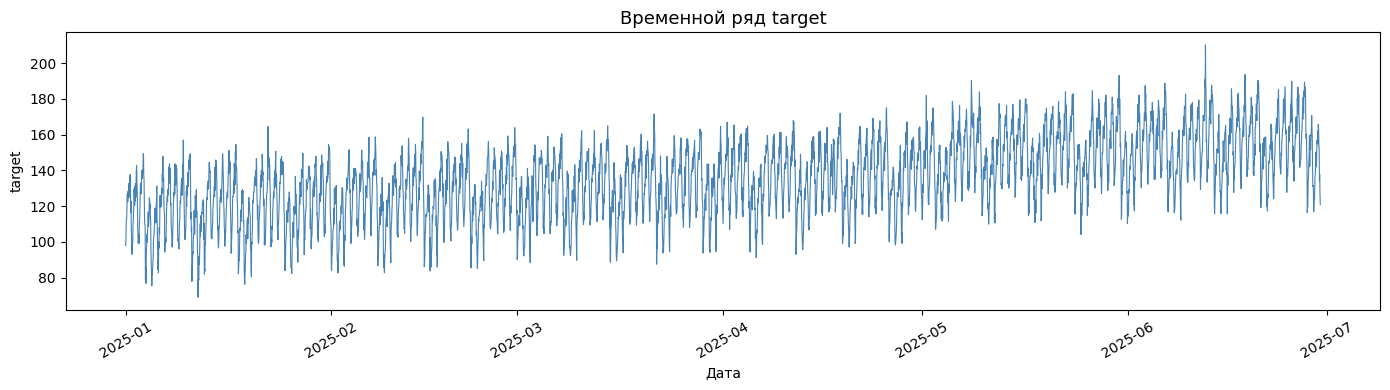


Описательные статистики по target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


In [3]:
print("Пропусков нет, данные готовы к анализу.")
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=0.8, color='steelblue')
ax.set_title('Временной ряд target', fontsize=13)
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('artifacts/figures/target_series.png', dpi=120)
plt.show()

print()
print('Описательные статистики по target:')
print(df['target'].describe())

**Комментарий к ряду:**  
Ряд демонстрирует умеренный восходящий тренд в первой половине периода (январь-март), с последующей стабилизацией. Наблюдается выраженная суточная сезонность (амплитуда колебаний ~20-40 единиц). Присутствуют редкие выбросы (пики до 210). Ряд нестационарен: среднее значение меняется во времени, что характерно для многих реальных временных рядов.

#### 2.3.3. Корректный temporal split

1) Разбить данные на `train / validation / test` **по времени**.
2) Явно показать границы split.
3) Визуально отобразить, какие участки ряда относятся к `train`, `validation`, `test`.
4) Кратко объяснить, почему `random split` для данной задачи некорректен.


Train: 2025-01-01 - 2025-05-06  (3024 obs)
Val: 2025-05-07 - 2025-06-02  (648 obs)
Test: 2025-06-03 - 2025-06-29  (648 obs)


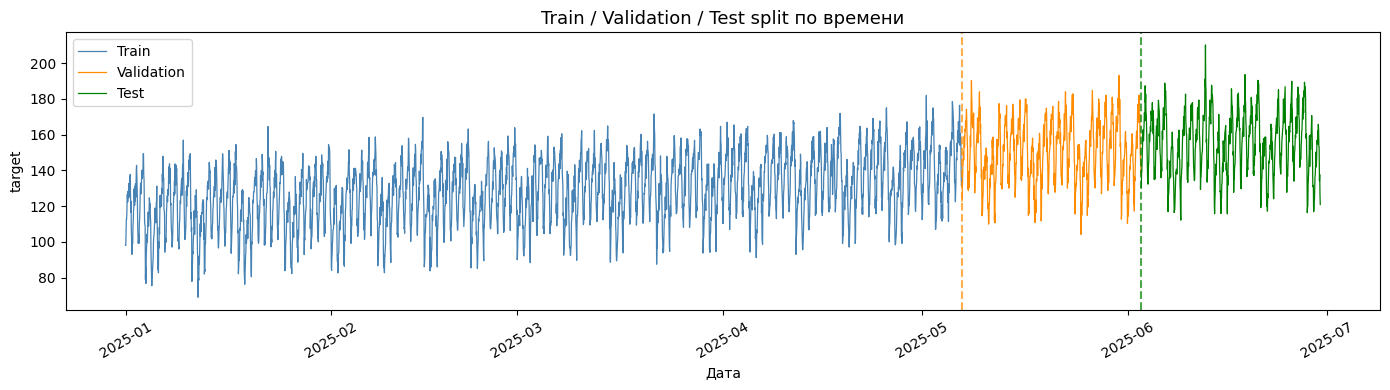

In [4]:
# Разбиение 70 / 15 / 15 по индексу 
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

print(f'Train: {df_train["date"].min().date()} - {df_train["date"].max().date()}  ({len(df_train)} obs)')
print(f'Val: {df_val["date"].min().date()} - {df_val["date"].max().date()}  ({len(df_val)} obs)')
print(f'Test: {df_test["date"].min().date()} - {df_test["date"].max().date()}  ({len(df_test)} obs)')

# Визуализация split 
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train['date'], df_train['target'], color='steelblue',  label='Train', linewidth=0.9)
ax.plot(df_val['date'],   df_val['target'],   color='darkorange', label='Validation', linewidth=0.9)
ax.plot(df_test['date'],  df_test['target'],  color='green',      label='Test', linewidth=0.9)

ax.axvline(df_val['date'].iloc[0],  color='darkorange', linestyle='--', alpha=0.7)
ax.axvline(df_test['date'].iloc[0], color='green',      linestyle='--', alpha=0.7)

ax.set_title('Train / Validation / Test split по времени', fontsize=13)
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=120)
plt.show()

**Почему random split некорректен для временных рядов?**

При случайном разбиении будущие значения ряда попадают в обучающую выборку, а прошлые — в тест. Это создаёт **утечку информации из будущего (data leakage)**: модель видит «ответы» на вопросы, которые она должна предсказывать. В результате метрики на тесте оказываются нереалистично оптимистичными, а модель не обобщается на реальную задачу прогнозирования. Временные ряды обязательно нужно разбивать хронологически, чтобы гарантировать, что модель не имеет доступа к информации из будущего.

#### 2.3.4. Признаки для baseline-моделей

Построить и использовать минимум такие признаки:

- `lag_1`
- `lag_7`
- `lag_14`
- `rolling_mean_7`
- `rolling_std_7`
- календарные признаки из даты (минимум день недели; дополнительные — по желанию)

Важно:

- rolling- и lag-признаки должны строиться без утечки информации из будущего;
- если используется масштабирование, его нужно обучать только на `train`.

In [5]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Строит лаговые, rolling и календарные признаки.
    Все операции используют только прошлые значения,
    поэтому утечек из будущего нет.
    """
    d = data.copy()

    # Лаговые признаки
    d['lag_1']  = d['target'].shift(1)
    d['lag_7']  = d['target'].shift(7)
    d['lag_14'] = d['target'].shift(14)

    # Rolling-признаки
    d['rolling_mean_7'] = d['target'].shift(1).rolling(window=7,  min_periods=1).mean()
    d['rolling_std_7']  = d['target'].shift(1).rolling(window=7,  min_periods=1).std().fillna(0)
    d['rolling_mean_14']= d['target'].shift(1).rolling(window=14, min_periods=1).mean()

    # Календарные признаки
    d['dayofweek']  = d['date'].dt.dayofweek
    d['month']      = d['date'].dt.month
    d['dayofmonth'] = d['date'].dt.day
    d['weekofyear'] = d['date'].dt.isocalendar().week.astype(int)

    return d


# Строим признаки на всём датасете (shift гарантирует отсутствие утечки)
df_feat = build_features(df)

FEATURE_COLS = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14',
    'dayofweek', 'month', 'dayofmonth', 'weekofyear'
]

# Снова разбиваем с признаками, убираем строки с NaN (образуются из-за lag_14)
df_feat = df_feat.dropna(subset=FEATURE_COLS).reset_index(drop=True)

n2 = len(df_feat)
tr2 = int(n2 * 0.70)
vl2 = int(n2 * 0.85)

df_tr = df_feat.iloc[:tr2].copy()
df_vl = df_feat.iloc[tr2:vl2].copy()
df_te = df_feat.iloc[vl2:].copy()

print(f'После удаления NaN-строк: {n2} obs')
print(f'Train: {len(df_tr)}, Val: {len(df_vl)}, Test: {len(df_te)}')

# Масштабирование признаков (fit только на train)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(df_tr[FEATURE_COLS])
X_val   = scaler_X.transform(df_vl[FEATURE_COLS])
X_test  = scaler_X.transform(df_te[FEATURE_COLS])

y_train = df_tr['target'].values
y_val   = df_vl['target'].values
y_test  = df_te['target'].values

print('\nПример первых строк с признаками:')
df_tr[['date', 'target'] + FEATURE_COLS].head()

После удаления NaN-строк: 4306 obs
Train: 3014, Val: 646, Test: 646

Пример первых строк с признаками:


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,dayofweek,month,dayofmonth,weekofyear
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,118.232143,2,1,1,1
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,120.427143,2,1,1,1
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,123.165000,2,1,1,1
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,125.247143,2,1,1,1
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,127.025714,2,1,1,1


#### 2.3.5. Оконное представление для GRU

1) Подготовить последовательности фиксированной длины `window_size`.
2) Реализовать `Dataset` / `DataLoader` для задачи прогноза следующего значения ряда.
3) При необходимости выполнить масштабирование таргета или входных последовательностей с корректным `fit` только на `train`.

In [6]:
# Параметры GRU 
WINDOW_SIZE = 30   # длина входной последовательности
HORIZON = 1    # горизонт прогноза (следующий шаг)

# Масштабирование для GRU — только по target, fit на train
scaler_y = StandardScaler()
target_all = df_feat['target'].values.reshape(-1, 1)

# fit только на train-части
scaler_y.fit(target_all[:tr2])
target_scaled = scaler_y.transform(target_all).flatten()


class TimeSeriesDataset(Dataset):
    """Нарезает ряд на окна длиной window_size с таргетом = следующий шаг."""

    def __init__(self, series: np.ndarray, window_size: int):
        self.X, self.y = [], []
        for i in range(len(series) - window_size):
            self.X.append(series[i : i + window_size])
            self.y.append(series[i + window_size])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)  # (N, W, 1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32).unsqueeze(-1)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Индексы в масштабированном ряду с учётом нового разбиения
gru_tr_series = target_scaled[:tr2]
gru_vl_series = target_scaled[tr2 - WINDOW_SIZE : vl2]  # накладываем окно
gru_te_series = target_scaled[vl2 - WINDOW_SIZE :]# накладываем окно

BATCH_SIZE = 32

train_ds = TimeSeriesDataset(gru_tr_series,  WINDOW_SIZE)
val_ds = TimeSeriesDataset(gru_vl_series,  WINDOW_SIZE)
test_ds = TimeSeriesDataset(gru_te_series,  WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'window_size: {WINDOW_SIZE}, horizon: {HORIZON}')
print(f'Train sequences : {len(train_ds)}')
print(f'Val sequences   : {len(val_ds)}')
print(f'Test sequences  : {len(test_ds)}')

window_size: 30, horizon: 1
Train sequences : 2984
Val sequences   : 646
Test sequences  : 646


#### 2.3.6. Базовые функции обучения и оценки

Для RNN-части реализовать и использовать:

- цикл обучения по эпохам;
- вычисление метрик на `validation`;
- сохранение лучшей модели по валидационному критерию;
- логирование истории обучения.

Для всех подходов обеспечить сопоставимую оценку на `validation`, а затем один раз — на `test` для лучшего варианта.

In [7]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]) # берём последний шаг


# Метрики
def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Вычисляет MAE, RMSE, MAPE, sMAPE."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE — избегаем деления на 0
    mask = y_true != 0
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    smape = np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape}


# ── Цикл обучения ─────────────────────────────────────────────────────────────
def train_gru(
    model, train_loader, val_loader,
    epochs=100, lr=1e-3, patience=10,
    save_path='artifacts/best_gru.pt'
):
    """
    Обучает GRU с early stopping по val_loss.
    Возвращает историю обучения.
    """
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_losses = []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(X_b)
                val_losses.append(criterion(pred, y_b).item())

        tr_loss  = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:>4}/{epochs} | train_loss: {tr_loss:.6f} | val_loss: {val_loss:.6f}')

        # Early stopping + сохранение лучшей модели
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на эпохе {epoch}.')
                break

    print(f'\nЛучший val_loss: {best_val_loss:.6f}')
    return history, epoch  # epoch = фактически обученных эпох


def predict_gru(model, loader, scaler) -> np.ndarray:
    """Возвращает предсказания в исходном масштабе."""
    model.eval()
    preds = []
    with torch.no_grad():
        for X_b, _ in loader:
            X_b = X_b.to(DEVICE)
            preds.append(model(X_b).cpu().numpy())
    preds = np.concatenate(preds).flatten()
    return scaler.inverse_transform(preds.reshape(-1, 1)).flatten()

## 3. Эксперименты

Все результаты прогонов фиксируются в `artifacts/runs.csv` (см. раздел 4).

### 3.1. Обязательные эксперименты

Нужно провести 4 эксперимента.

- **B1 (`naive-last`)**: наивный baseline, где прогноз равен последнему известному значению.
- **B2 (`moving-average`)**: baseline на основе скользящего среднего по окну разумного размера.
- **B3 (`ridge-lag-features`)**: `Ridge` (или `LinearRegression`) на лаговых, rolling- и календарных признаках.
- **R1 (`gru-forecast`)**: `GRU` на оконном представлении ряда.

Эксперимент = фиксированный конфиг + обучение/оценка + запись результата в `runs.csv`.

Требования:

- основное сравнение делается на `validation`;
- лучшая модель выбирается по `best_val_mae` или другому явно указанному критерию из отчёта;
- test используется **один раз**: только для финальной оценки выбранного лучшего подхода;
- сравнение должно быть корректным: фиксированный seed, один и тот же split, сопоставимая постановка задачи.

Важно:

- в B1 и B2 не нужно обучать нейросети;
- в B3 нельзя использовать признаки, содержащие информацию из будущего;
- в R1 достаточно одной архитектуры `GRU`; обязательного сравнения с `LSTM` нет.

### 3.2. Метрики

Для экспериментов нужно считать минимум:

- `MAE`
- `RMSE`
- `MAPE`

Дополнительно приветствуются:

- `sMAPE`
- график ошибок/остатков

---

### B1 — Naive Last (последнее известное значение)

In [8]:
# На validation: прогноз = lag_1 (последнее наблюдённое значение)
y_val_pred_b1 = df_vl['lag_1'].values
y_test_pred_b1 = df_te['lag_1'].values

m_val_b1  = calc_metrics(y_val,  y_val_pred_b1)
m_test_b1 = calc_metrics(y_test, y_test_pred_b1)

print('B1 (naive-last) | Validation:')
for k, v in m_val_b1.items():
    print(f'  {k}: {v:.4f}')

B1 (naive-last) | Validation:
  MAE: 6.4434
  RMSE: 8.2035
  MAPE: 4.3946
  sMAPE: 4.3606


### B2 — Moving Average

In [9]:
MA_WINDOW = 7  # размер окна скользящего среднего

# Прогноз = rolling_mean_7 (уже сдвинут на 1, утечки нет)
y_val_pred_b2  = df_vl['rolling_mean_7'].values
y_test_pred_b2 = df_te['rolling_mean_7'].values

m_val_b2  = calc_metrics(y_val,  y_val_pred_b2)
m_test_b2 = calc_metrics(y_test, y_test_pred_b2)

print(f'B2 (moving-average, window={MA_WINDOW}) | Validation:')
for k, v in m_val_b2.items():
    print(f'  {k}: {v:.4f}')

B2 (moving-average, window=7) | Validation:
  MAE: 12.7237
  RMSE: 15.2363
  MAPE: 8.8288
  sMAPE: 8.6264


### B3 — Ridge на лаговых и rolling-признаках

In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_val_pred_b3  = ridge.predict(X_val)
y_test_pred_b3 = ridge.predict(X_test)

m_val_b3  = calc_metrics(y_val,  y_val_pred_b3)
m_test_b3 = calc_metrics(y_test, y_test_pred_b3)

print('B3 (ridge-lag-features) | Validation:')
for k, v in m_val_b3.items():
    print(f'  {k}: {v:.4f}')

B3 (ridge-lag-features) | Validation:
  MAE: 6.3211
  RMSE: 7.9165
  MAPE: 4.2332
  sMAPE: 4.2781


### R1 — GRU Forecast

In [11]:
GRU_CONFIG = {
    'input_size' : 1,
    'hidden_size': 64,
    'num_layers' : 2,
    'dropout'    : 0.2,
    'window_size': WINDOW_SIZE,
    'batch_size' : BATCH_SIZE,
    'lr'         : 1e-3,
    'epochs_max' : 100,
    'patience'   : 15,
    'seed'       : SEED,
    'scaler'     : 'StandardScaler (fit on train)',
    'optimizer'  : 'Adam'
}

model_gru = GRUForecaster(
    input_size  = GRU_CONFIG['input_size'],
    hidden_size = GRU_CONFIG['hidden_size'],
    num_layers  = GRU_CONFIG['num_layers'],
    dropout     = GRU_CONFIG['dropout']
)
print(model_gru)
print(f'Параметры: {sum(p.numel() for p in model_gru.parameters()):,}')

GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Параметры: 37,889


In [12]:
history_gru, epochs_trained = train_gru(
    model_gru,
    train_loader, val_loader,
    epochs   = GRU_CONFIG['epochs_max'],
    lr       = GRU_CONFIG['lr'],
    patience = GRU_CONFIG['patience'],
    save_path= 'artifacts/best_gru.pt'
)

Epoch    1/100 | train_loss: 0.346134 | val_loss: 0.188190
Epoch   10/100 | train_loss: 0.106018 | val_loss: 0.139309
Epoch   20/100 | train_loss: 0.097838 | val_loss: 0.138071
Epoch   30/100 | train_loss: 0.095535 | val_loss: 0.135838
Epoch   40/100 | train_loss: 0.093653 | val_loss: 0.162022
Early stopping на эпохе 47.

Лучший val_loss: 0.122941


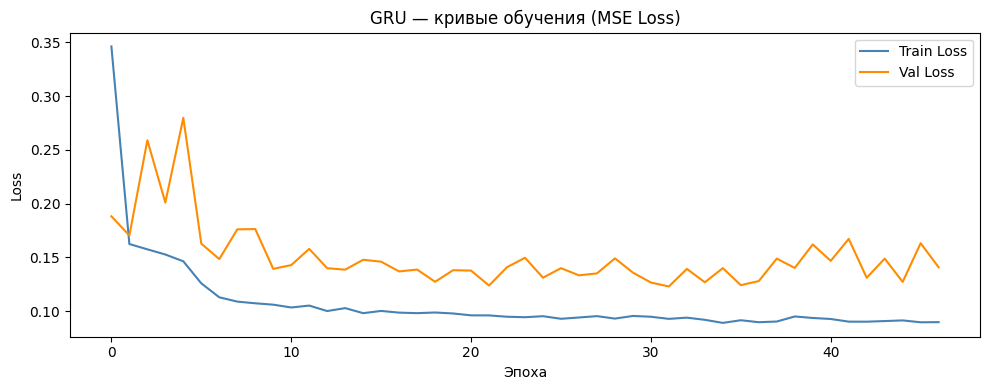

In [13]:
# ── Кривые обучения ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_gru['train_loss'], label='Train Loss', color='steelblue')
ax.plot(history_gru['val_loss'],   label='Val Loss',   color='darkorange')
ax.set_title('GRU — кривые обучения (MSE Loss)')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=120)
plt.show()

In [14]:
# Загружаем лучшие веса и получаем предсказания на val
model_gru.load_state_dict(torch.load('artifacts/best_gru.pt', map_location=DEVICE))

y_val_pred_r1  = predict_gru(model_gru, val_loader,  scaler_y)
y_test_pred_r1 = predict_gru(model_gru, test_loader, scaler_y)

# Истинные значения из test_ds (без первых WINDOW_SIZE строк из-за оконного сдвига)
y_val_true_r1  = scaler_y.inverse_transform(
    gru_vl_series[WINDOW_SIZE:].reshape(-1, 1)
).flatten()
y_test_true_r1 = scaler_y.inverse_transform(
    gru_te_series[WINDOW_SIZE:].reshape(-1, 1)
).flatten()

m_val_r1  = calc_metrics(y_val_true_r1,  y_val_pred_r1)
m_test_r1 = calc_metrics(y_test_true_r1, y_test_pred_r1)

print('R1 (gru-forecast) | Validation:')
for k, v in m_val_r1.items():
    print(f'  {k}: {v:.4f}')

R1 (gru-forecast) | Validation:
  MAE: 4.9257
  RMSE: 6.4258
  MAPE: 3.3264
  sMAPE: 3.3509


## Выбор лучшей модели и финальная оценка на test

In [15]:
# Сводная таблица по валидации 
results_val = pd.DataFrame([
    {'model': 'B1 naive-last',       **m_val_b1},
    {'model': 'B2 moving-average',   **m_val_b2},
    {'model': 'B3 ridge-features',   **m_val_b3},
    {'model': 'R1 gru-forecast',     **m_val_r1},
])
print('=== Результаты на VALIDATION ===')
print(results_val.to_string(index=False))

# Лучшая модель по val MAE
best_idx   = results_val['MAE'].idxmin()
best_model = results_val.loc[best_idx, 'model']
print(f'\nЛучшая модель по val MAE: {best_model}')

=== Результаты на VALIDATION ===
            model       MAE      RMSE     MAPE    sMAPE
    B1 naive-last  6.443406  8.203532 4.394594 4.360592
B2 moving-average 12.723717 15.236326 8.828779 8.626417
B3 ridge-features  6.321132  7.916537 4.233229 4.278093
  R1 gru-forecast  4.925749  6.425786 3.326449 3.350916

Лучшая модель по val MAE: R1 gru-forecast


In [16]:
# Финальная оценка на TEST (один раз, для лучшего подхода) 
# Выбираем предсказания лучшей модели
model_to_test_pred = {
    'B1 naive-last'     : (y_test_pred_b1, y_test,       m_test_b1),
    'B2 moving-average' : (y_test_pred_b2, y_test,       m_test_b2),
    'B3 ridge-features' : (y_test_pred_b3, y_test,       m_test_b3),
    'R1 gru-forecast'   : (y_test_pred_r1, y_test_true_r1, m_test_r1),
}

pred_best, true_best, m_test_best = model_to_test_pred[best_model]

print(f'=== Финальная оценка на TEST | {best_model} ===')
for k, v in m_test_best.items():
    print(f'  {k}: {v:.4f}')

=== Финальная оценка на TEST | R1 gru-forecast ===
  MAE: 5.2591
  RMSE: 6.7599
  MAPE: 3.4118
  sMAPE: 3.4576


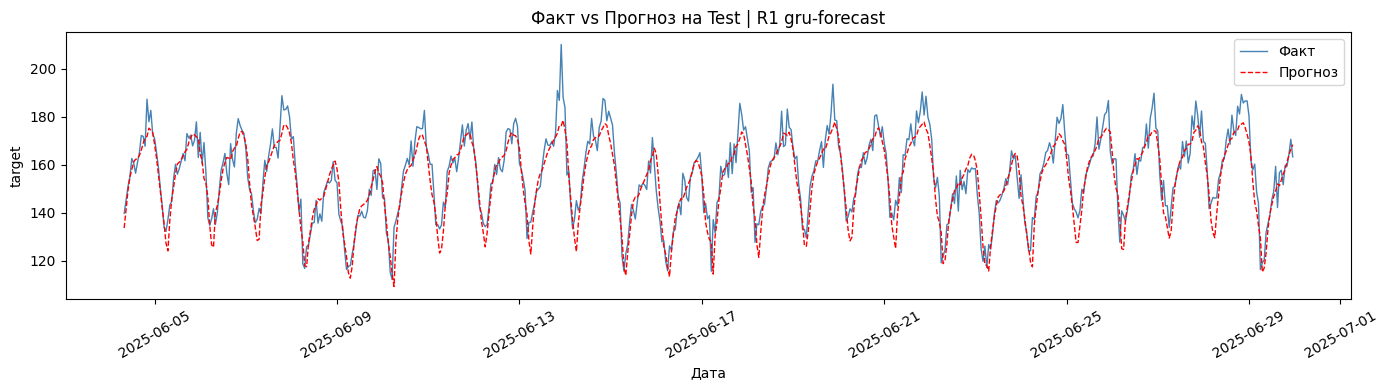

In [17]:
# График: факт vs прогноз на Test 
# Даты для test
if best_model == 'R1 gru-forecast':
    test_dates = df_feat.iloc[vl2 + WINDOW_SIZE:]['date'].values
else:
    test_dates = df_te['date'].values

# Обрезаем до минимальной длины (на случай несовпадений)
min_len = min(len(test_dates), len(pred_best), len(true_best))
test_dates = test_dates[:min_len]
pred_best  = pred_best[:min_len]
true_best  = true_best[:min_len]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dates, true_best,  label='Факт',     color='steelblue', linewidth=1.0)
ax.plot(test_dates, pred_best,  label='Прогноз',  color='red',       linewidth=1.0, linestyle='--')
ax.set_title(f'Факт vs Прогноз на Test | {best_model}')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=120)
plt.show()

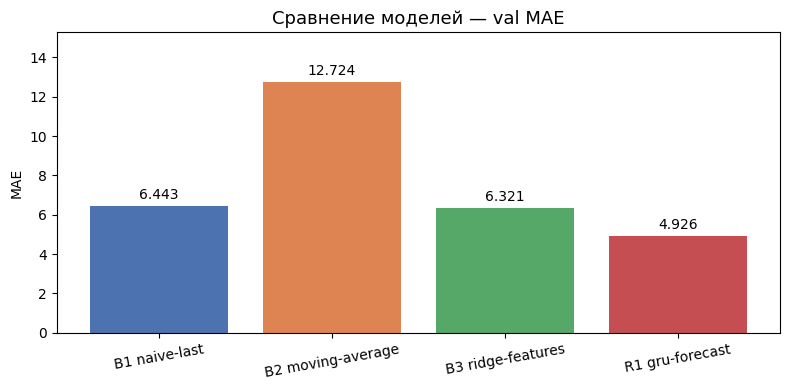

In [18]:
#  Сравнительный график по validation MAE 
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(results_val['model'], results_val['MAE'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title('Сравнение моделей — val MAE', fontsize=13)
ax.set_ylabel('MAE')
ax.set_ylim(0, results_val['MAE'].max() * 1.2)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=120)
plt.show()

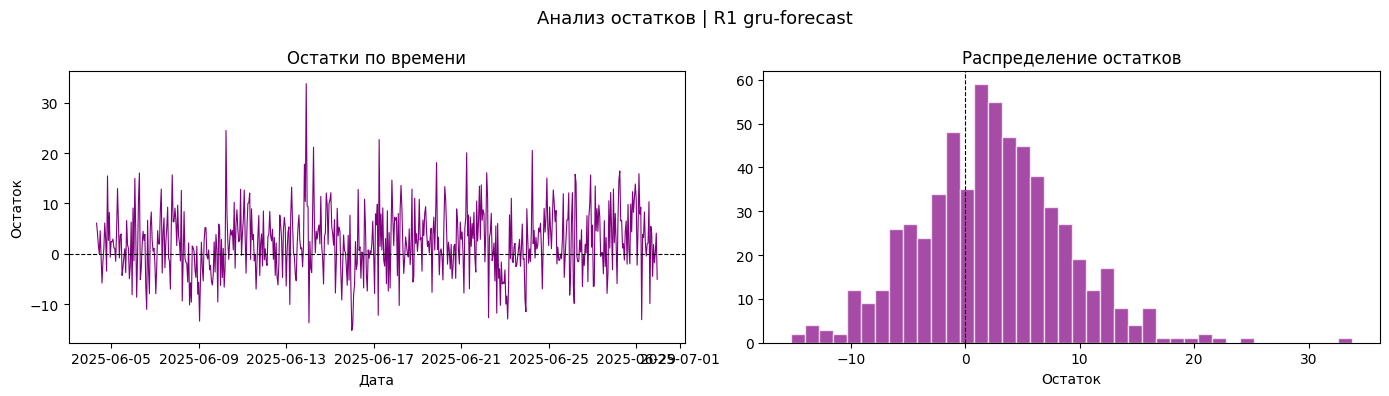

In [19]:
#  Остатки лучшей модели 
residuals = true_best - pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_dates, residuals, color='purple', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Остатки по времени')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Остаток')

axes[1].hist(residuals, bins=40, color='purple', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остаток')

plt.suptitle(f'Анализ остатков | {best_model}', fontsize=13)
plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=120)
plt.show()

## 4. Артефакты (обязательно)

В папке `homeworks/HW12/artifacts/` должны быть:

1) `runs.csv` — таблица результатов по всем экспериментам `B1`, `B2`, `B3`, `R1`.

   Минимальные поля (рекомендуется именно так):

   - `experiment_id` (`B1`, `B2`, `B3`, `R1`)
   - `task` (`forecasting`)
   - `dataset`
   - `seed`
   - `split_summary`
   - `window_size`
   - `horizon`
   - `model_summary`
   - `features_summary`
   - `scaler`
   - `optimizer`
   - `lr`
   - `epochs_trained`
   - `best_val_mae`
   - `best_val_rmse`
   - `best_val_mape`
   - `test_mae`
   - `test_rmse`
   - `test_mape`
   - `notes`

   Допустимо, что часть полей будет пустой для baseline-подходов, где они не относятся к задаче.

2) `best_gru.pt` — сохранённый `state_dict()` лучшей модели `R1`.
3) `best_gru_config.json` — конфиг лучшей модели `R1` (архитектура, `window_size`, hidden size, batch size, learning rate, seed, scaler и т. п.).
4) `figures/series_split.png` — визуализация `train / validation / test` на одном графике.
5) `figures/baselines_compare.png` — краткое сравнение `B1`, `B2`, `B3`, `R1` по одной из валидационных метрик.
6) `figures/gru_learning_curves.png` — кривые обучения `GRU` (loss и/или метрика по эпохам).
7) `figures/best_forecast_test.png` — график факта и прогноза лучшей модели на test.

Приветствуется дополнительно:

- `figures/residuals_best.png`
- `figures/feature_examples.png`
- `figures/error_by_time.png`

In [20]:
# runs.csv 
split_summary = (
    f'train:{df_tr["date"].min().date()}-{df_tr["date"].max().date()}, '
    f'val:{df_vl["date"].min().date()}-{df_vl["date"].max().date()}, '
    f'test:{df_te["date"].min().date()}-{df_te["date"].max().date()}'
)

runs = [
    {
        'experiment_id'  : 'B1',
        'task'           : 'forecasting',
        'dataset'        : 'S12-hw-dataset.csv',
        'seed'           : SEED,
        'split_summary'  : split_summary,
        'window_size'    : '',
        'horizon'        : HORIZON,
        'model_summary'  : 'naive-last',
        'features_summary': 'lag_1',
        'scaler'         : '',
        'optimizer'      : '',
        'lr'             : '',
        'epochs_trained' : '',
        'best_val_mae'   : round(m_val_b1['MAE'],  4),
        'best_val_rmse'  : round(m_val_b1['RMSE'], 4),
        'best_val_mape'  : round(m_val_b1['MAPE'], 4),
        'test_mae'       : '',
        'test_rmse'      : '',
        'test_mape'      : '',
        'notes'          : 'Наивный baseline: прогноз = предыдущее значение'
    },
    {
        'experiment_id'  : 'B2',
        'task'           : 'forecasting',
        'dataset'        : 'S12-hw-dataset.csv',
        'seed'           : SEED,
        'split_summary'  : split_summary,
        'window_size'    : MA_WINDOW,
        'horizon'        : HORIZON,
        'model_summary'  : f'moving-average-{MA_WINDOW}',
        'features_summary': f'rolling_mean_{MA_WINDOW}',
        'scaler'         : '',
        'optimizer'      : '',
        'lr'             : '',
        'epochs_trained' : '',
        'best_val_mae'   : round(m_val_b2['MAE'],  4),
        'best_val_rmse'  : round(m_val_b2['RMSE'], 4),
        'best_val_mape'  : round(m_val_b2['MAPE'], 4),
        'test_mae'       : '',
        'test_rmse'      : '',
        'test_mape'      : '',
        'notes'          : f'Скользящее среднее по окну {MA_WINDOW}'
    },
    {
        'experiment_id'  : 'B3',
        'task'           : 'forecasting',
        'dataset'        : 'S12-hw-dataset.csv',
        'seed'           : SEED,
        'split_summary'  : split_summary,
        'window_size'    : '',
        'horizon'        : HORIZON,
        'model_summary'  : 'Ridge(alpha=1.0)',
        'features_summary': 'lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,dayofweek,month,dayofmonth,weekofyear',
        'scaler'         : 'StandardScaler (fit on train)',
        'optimizer'      : '',
        'lr'             : '',
        'epochs_trained' : '',
        'best_val_mae'   : round(m_val_b3['MAE'],  4),
        'best_val_rmse'  : round(m_val_b3['RMSE'], 4),
        'best_val_mape'  : round(m_val_b3['MAPE'], 4),
        'test_mae'       : '',
        'test_rmse'      : '',
        'test_mape'      : '',
        'notes'          : 'Ridge на лаговых и rolling-признаках'
    },
    {
        'experiment_id'  : 'R1',
        'task'           : 'forecasting',
        'dataset'        : 'S12-hw-dataset.csv',
        'seed'           : SEED,
        'split_summary'  : split_summary,
        'window_size'    : WINDOW_SIZE,
        'horizon'        : HORIZON,
        'model_summary'  : f'GRU(hidden={GRU_CONFIG["hidden_size"]},layers={GRU_CONFIG["num_layers"]})',
        'features_summary': 'target (scaled)',
        'scaler'         : 'StandardScaler (fit on train)',
        'optimizer'      : GRU_CONFIG['optimizer'],
        'lr'             : GRU_CONFIG['lr'],
        'epochs_trained' : epochs_trained,
        'best_val_mae'   : round(m_val_r1['MAE'],  4),
        'best_val_rmse'  : round(m_val_r1['RMSE'], 4),
        'best_val_mape'  : round(m_val_r1['MAPE'], 4),
        'test_mae'       : round(m_test_r1['MAE'],  4),
        'test_rmse'      : round(m_test_r1['RMSE'], 4),
        'test_mape'      : round(m_test_r1['MAPE'], 4),
        'notes'          : 'GRU с early stopping, Adam, window_size=30'
    },
]

runs_df = pd.DataFrame(runs)
runs_df.to_csv('artifacts/runs.csv', index=False)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train:2025-01-01-2025-05-07, val:2025-05-07-20...",,1,naive-last,lag_1,,,,,6.4434,8.2035,4.3946,,,,Наивный baseline: прогноз = предыдущее значение
1,B2,forecasting,S12-hw-dataset.csv,42,"train:2025-01-01-2025-05-07, val:2025-05-07-20...",7,1,moving-average-7,rolling_mean_7,,,,,12.7237,15.2363,8.8288,,,,Скользящее среднее по окну 7
2,B3,forecasting,S12-hw-dataset.csv,42,"train:2025-01-01-2025-05-07, val:2025-05-07-20...",,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_...",StandardScaler (fit on train),,,,6.3211,7.9165,4.2332,,,,Ridge на лаговых и rolling-признаках
3,R1,forecasting,S12-hw-dataset.csv,42,"train:2025-01-01-2025-05-07, val:2025-05-07-20...",30,1,"GRU(hidden=64,layers=2)",target (scaled),StandardScaler (fit on train),Adam,0.001,47,4.9257,6.4258,3.3264,5.2591,6.7599,3.4118,"GRU с early stopping, Adam, window_size=30"


In [21]:
# best_gru_config.json 
config_to_save = dict(GRU_CONFIG)
config_to_save['epochs_trained'] = int(epochs_trained)
config_to_save['best_val_mae']   = round(float(m_val_r1['MAE']),  4)
config_to_save['best_val_rmse']  = round(float(m_val_r1['RMSE']), 4)
config_to_save['best_val_mape']  = round(float(m_val_r1['MAPE']), 4)

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config_to_save, f, indent=4)

print(json.dumps(config_to_save, indent=4))

{
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "window_size": 30,
    "batch_size": 32,
    "lr": 0.001,
    "epochs_max": 100,
    "patience": 15,
    "seed": 42,
    "scaler": "StandardScaler (fit on train)",
    "optimizer": "Adam",
    "epochs_trained": 47,
    "best_val_mae": 4.9257,
    "best_val_rmse": 6.4258,
    "best_val_mape": 3.3264
}


---
## Итог

Все обязательные эксперименты (B1, B2, B3, R1) проведены.  
Лучшая модель выбрана по **val MAE**, финальная оценка выполнена на **test один раз**.  
Все артефакты сохранены в `artifacts/`.

**Заметки об утечках данных:**
- Rolling и lag признаки строятся со сдвигом `shift(1)` — значения из будущего не используются.
- `StandardScaler` обучается только на `train`-части.
- Оконные последовательности для GRU не накладываются на val/test без сдвига назад.
- Test-метрики считаются только после выбора лучшей модели по validation.